# 255: How well does each kmerseek ranking metric sort correct from incorrect Pfam matches?

**Question.** kmerseek 0.4 reports eleven scores for each matched region. Judged against
human Pfam annotations, how well does each one separate matches that land on the same
Pfam family from matches that do not? And does any of them do better than the length of
the matched region alone?

**Data.** An all-against-all search of the 998 human proteins that carry a Pfam domain in
the midi-plus truth set, with hp_lehninger2 at k = 24 (`labeled_pairs_overlap_rules.parquet`).
One row is one independent domain match: a pair of matched spans, counted once whichever
protein was the query (the direction with the lower E-value is kept). There are 5_649.
Section 7 repeats the main numbers for all 152 alphabet and k combinations of the
notebook 243 search of the same 998 proteins.

**Label.** A match is correct when its query span and its target span each overlap a
domain of the same Pfam family. "Overlap" has four readings, and every table and figure
names the one it uses:

| rule | a match is correct when, on both proteins, |
|---|---|
| any overlap | the span and the domain share at least one residue |
| ≥20% of the matched region inside the domain | at least 20% of the span lies inside the domain |
| ≥20% of the domain covered by the region | at least 20% of the domain lies inside the span |
| IoU ≥ 0.2 | the overlap divided by the union of span and domain (IoU) is at least 0.2 |

**Measures.**
- ROC AUC (area under the receiver operating characteristic curve): the chance that a
  randomly picked correct match scores higher than a randomly picked incorrect one. 0.5 is
  a coin toss, 1 is perfect.
- Average precision (AP, the area under the precision-recall curve): the precision
  averaged over every point where a correct match is recovered, going down the list. Its
  floor is the base rate, the fraction of matches that are correct, so AP is always shown
  next to the base rate.
- Accuracy, precision, recall and F1 at a cutoff, and MCC (Matthews correlation
  coefficient: the correlation between the call and the label, from -1 to 1, with 0 for
  calls unrelated to the label). MCC and F1 are not inflated by the many easy incorrect
  matches the way accuracy is.
- Per query protein: the chance that its top-ranked match is correct (precision at 1) and
  the mean of 1 / rank of its first correct match (mean reciprocal rank).

**Control.** Region length alone. In earlier work region_tfidf correlated with
region_length at Spearman rho 0.967. A metric is only useful if it does better than length
on the same matches.

**Uncertainty.** 95% intervals come from 1_000 resamples of query proteins (all matches of
a query move together, because they are not independent of each other).

In [1]:
import hashlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.metrics import roc_auc_score

sys.path.insert(0, str(Path.cwd()))
import ranking_metrics_utils as rm

pl.Config.set_tbl_rows(250)
pl.Config.set_tbl_cols(30)
pl.Config.set_tbl_width_chars(250)
pl.Config.set_fmt_str_lengths(50)
pl.Config.set_float_precision(3)
rm.setup_style()
FIG = rm.FIG
N_BOOT = 1_000
COLS = [c for c, _, _ in rm.ALL]
RULES = [r for r, _ in rm.RULES]

df = pl.read_parquet(rm.LABELS)
print(f"{rm.LABELS}")
print(f"md5 {hashlib.md5(rm.LABELS.read_bytes()).hexdigest()}  sha256 {hashlib.sha256(rm.LABELS.read_bytes()).hexdigest()}")
print(f"{df.height:_} matches, {df['query_name'].n_unique():_} query proteins, "
      f"alphabet {df['moltype'].unique().to_list()}, k {df['ksize'].unique().to_list()}, "
      f"scaled {df['scaled'].unique().to_list()}, low-complexity removed {df['remove_low_complexity'].unique().to_list()}, "
      f"{df['db_n_targets'].unique().to_list()} proteins in the index")
print(df.select([pl.col(r).sum().alias(rm.RULE_NAME[r]) for r in RULES]).with_columns(pl.lit("correct").alias("")))

/Users/olga/data/botryllus/ranking-metrics/labeled_pairs_overlap_rules.parquet
md5 1e3958e9568d47d3d677e58e56158b1b  sha256 06ba115c9d5fd1132b9b3235cdcb03cbb83483655efdb74a993a74f8e4fab194
5_649 matches, 917 query proteins, alphabet ['hp_lehninger2'], k [24], scaled [1], low-complexity removed [True], [989] proteins in the index
shape: (1, 5)
┌─────────────┬──────────────────────────────────────────────┬──────────────────────────────────────────┬───────────┬─────────┐
│ any overlap ┆ ≥20% of the matched region inside the domain ┆ ≥20% of the domain covered by the region ┆ IoU ≥ 0.2 ┆         │
│ ---         ┆ ---                                          ┆ ---                                      ┆ ---       ┆ ---     │
│ u32         ┆ u32                                          ┆ u32                                      ┆ u32       ┆ str     │
╞═════════════╪══════════════════════════════════════════════╪══════════════════════════════════════════╪═══════════╪═════════╡
│ 808         ┆

## 1. The labels can be rebuilt from the Pfam truth

`label_regions` recomputes the four rules from the region coordinates and the midi-plus
human domain truth (kmerseek starts are 0-based, ends inclusive). It agrees with every
stored label. The same function labels the 152 alphabet-ksize pairs in section 7.

In [2]:
rebuilt = rm.label_regions(df.drop(RULES))
check = pl.DataFrame({"rule": [rm.RULE_NAME[r] for r in RULES],
                      "stored correct": [int(df[r].sum()) for r in RULES],
                      "rebuilt correct": [int(rebuilt[r].sum()) for r in RULES],
                      "rows that disagree": [int((rebuilt[r] != df[r]).sum()) for r in RULES]})
print(check)
assert check["rows that disagree"].sum() == 0

shape: (4, 4)
┌──────────────────────────────────────────────┬────────────────┬─────────────────┬────────────────────┐
│ rule                                         ┆ stored correct ┆ rebuilt correct ┆ rows that disagree │
│ ---                                          ┆ ---            ┆ ---             ┆ ---                │
│ str                                          ┆ i64            ┆ i64             ┆ i64                │
╞══════════════════════════════════════════════╪════════════════╪═════════════════╪════════════════════╡
│ any overlap                                  ┆ 808            ┆ 808             ┆ 0                  │
│ ≥20% of the matched region inside the domain ┆ 687            ┆ 687             ┆ 0                  │
│ ≥20% of the domain covered by the region     ┆ 765            ┆ 765             ┆ 0                  │
│ IoU ≥ 0.2                                    ┆ 653            ┆ 653             ┆ 0                  │
└────────────────────────────────────────

## 2. What each metric can score, and ties

A metric cannot rank a match that has no value. For 2_005 matches kmerseek found no
Karlin-Altschul lambda (the per-region scale that turns a score into bits); it writes
E = inf and a bit score of 0 there. Both are treated as missing, not ranked. The two
Poisson p-values reach 0 (below the smallest number a computer stores) on hundreds of
matches, and all of those tie at the top.

In [3]:
ties = rm.ties_and_missing(df, COLS)
print(ties)
assert (ties["n_scored"] + ties["n_null_or_inf"] + ties["n_no_lambda"] == df.height).all()
print(f"\nscored + no value = {df.height:_} for every metric")

# Are the matches without a lambda a random subset? Compare them with the rest.
nolam = df["region_ka_lambda"] == 0
print(pl.DataFrame({
    "matches": ["no lambda (E = inf)", "lambda > 0"],
    "n": [int(nolam.sum()), int((~nolam).sum())],
    "median region length (aa)": [df.filter(nolam)["region_length"].median(), df.filter(~nolam)["region_length"].median()],
    **{f"correct, {rm.RULE_NAME[r]}": [int(df.filter(nolam)[r].sum()), int(df.filter(~nolam)[r].sum())] for r in RULES},
}))

shape: (12, 9)
┌─────────────────────────┬─────────────────────────┬───────────┬──────────┬───────────────┬─────────────┬───────────────┬───────────────┬───────────────────┐
│ metric                  ┆ column                  ┆ n_matches ┆ n_scored ┆ n_null_or_inf ┆ n_no_lambda ┆ frac_unscored ┆ n_tied_at_top ┆ n_distinct_values │
│ ---                     ┆ ---                     ┆ ---       ┆ ---      ┆ ---           ┆ ---         ┆ ---           ┆ ---           ┆ ---               │
│ str                     ┆ str                     ┆ i64       ┆ i64      ┆ i64           ┆ i64         ┆ f64           ┆ i64           ┆ i64               │
╞═════════════════════════╪═════════════════════════╪═══════════╪══════════╪═══════════════╪═════════════╪═══════════════╪═══════════════╪═══════════════════╡
│ E-value                 ┆ region_evalue           ┆ 5649      ┆ 3644     ┆ 2005          ┆ 0           ┆ 0.355         ┆ 1             ┆ 3388              │
│ bit score               ┆ reg

## 3. ROC AUC and average precision, per labelling rule

Each metric is scored on the matches it can score. For the E-value and bit score that is
3_644 of 5_649, so the grey bar (region length) is recomputed on those same 3_644, and the
base rate differs. `auc_unscored_last` and `ap_unscored_last` put the 2_005 unscored matches
at the bottom of the list instead, over all 5_649.

In [4]:
boot = pl.concat([rm.bootstrap(df, r, COLS, n_boot=N_BOOT) for r in RULES])
show = ["rule", "metric", "n_scored", "n_correct", "base_rate", "auc", "auc_lo", "auc_hi", "length_auc",
        "ap", "ap_lo", "ap_hi", "length_ap", "auc_unscored_last", "ap_unscored_last"]
for r in RULES:
    print(boot.filter(pl.col("rule") == rm.RULE_NAME[r]).select(show))

# Paired comparison with length: metric minus length inside each resample, same matches.
diff = boot.filter(pl.col("metric") != "region length").select(
    "rule", "metric", "auc_minus_length", "auc_minus_length_lo", "auc_minus_length_hi",
    "ap_minus_length", "ap_minus_length_lo", "ap_minus_length_hi")
print("\nmetric minus region length on the same matches (95% interval from the same resamples)")
print(diff)
above_auc = diff.filter(pl.col("auc_minus_length_lo") > 0)
above_ap = diff.filter(pl.col("ap_minus_length_lo") > 0)
print(f"\nrows where the metric's ROC AUC is above length's with the interval above 0: {above_auc.height}")
print(f"rows where the metric's AP is above length's with the interval above 0: {above_ap.height}")
print(above_ap.select("rule", "metric", "ap_minus_length", "ap_minus_length_lo", "ap_minus_length_hi"))

shape: (12, 15)
┌─────────────┬─────────────────────────┬──────────┬───────────┬───────────┬───────┬────────┬────────┬────────────┬───────┬───────┬───────┬───────────┬───────────────────┬──────────────────┐
│ rule        ┆ metric                  ┆ n_scored ┆ n_correct ┆ base_rate ┆ auc   ┆ auc_lo ┆ auc_hi ┆ length_auc ┆ ap    ┆ ap_lo ┆ ap_hi ┆ length_ap ┆ auc_unscored_last ┆ ap_unscored_last │
│ ---         ┆ ---                     ┆ ---      ┆ ---       ┆ ---       ┆ ---   ┆ ---    ┆ ---    ┆ ---        ┆ ---   ┆ ---   ┆ ---   ┆ ---       ┆ ---               ┆ ---              │
│ str         ┆ str                     ┆ i64      ┆ i64       ┆ f64       ┆ f64   ┆ f64    ┆ f64    ┆ f64        ┆ f64   ┆ f64   ┆ f64   ┆ f64       ┆ f64               ┆ f64              │
╞═════════════╪═════════════════════════╪══════════╪═══════════╪═══════════╪═══════╪════════╪════════╪════════════╪═══════╪═══════╪═══════╪═══════════╪═══════════════════╪══════════════════╡
│ any overlap ┆ E-value      

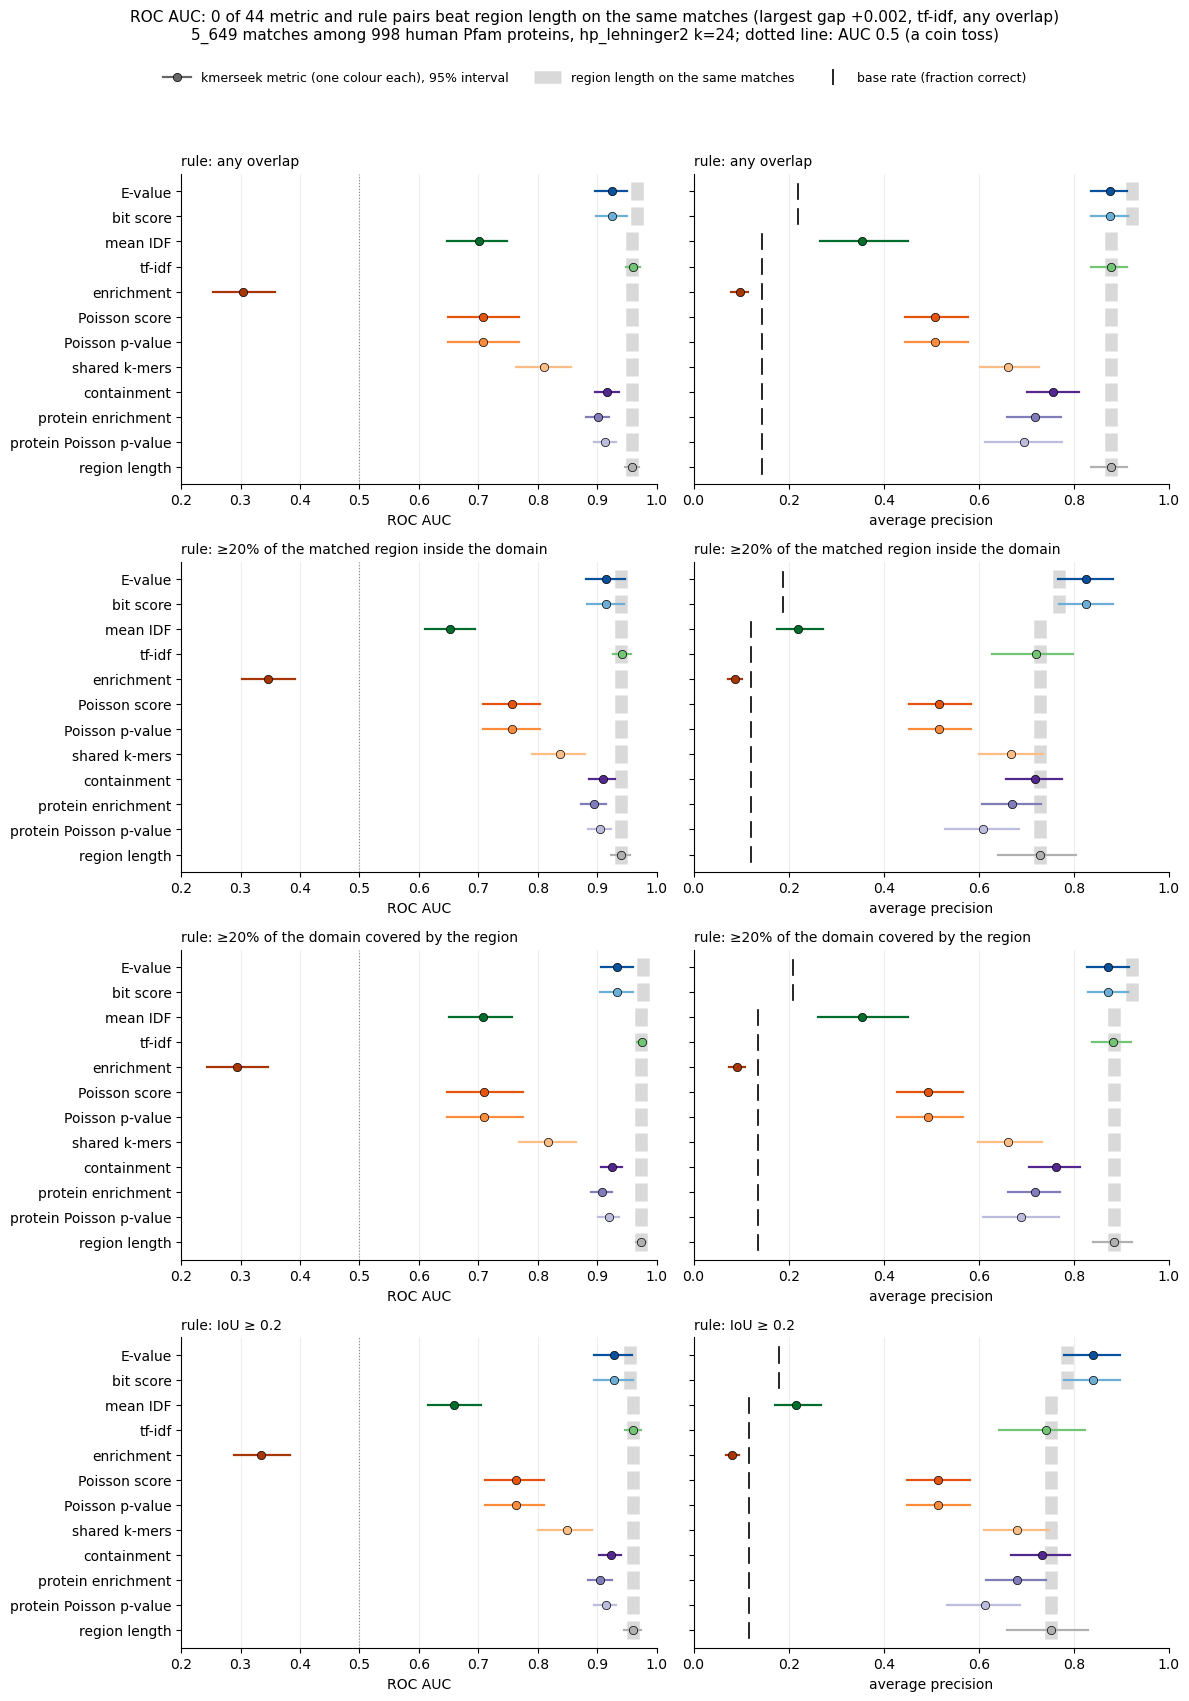

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(12, 17), sharey=True)
for i, r in enumerate(RULES):
    t = boot.filter(pl.col("rule") == rm.RULE_NAME[r])
    rm.forest(axes[i, 0], t, "auc", "auc_lo", "auc_hi", "length_auc", xlabel="ROC AUC", xlim=(0.2, 1))
    axes[i, 0].axvline(0.5, color="#888888", lw=0.8, ls=":")
    rm.forest(axes[i, 1], t, "ap", "ap_lo", "ap_hi", "length_ap", tick="base_rate", xlabel="average precision")
    for ax in axes[i]:
        ax.set_title(f"rule: {rm.RULE_NAME[r]}", fontsize=10, loc="left")
rm.legend_row(fig, rm.handles("region length on the same matches", "base rate (fraction correct)"))
best = diff.sort("auc_minus_length", descending=True).row(0, named=True)
fig.suptitle(f"ROC AUC: {above_auc.height} of {diff.height} metric and rule pairs beat region length on the same matches "
             f"(largest gap {best['auc_minus_length']:+.3f}, {best['metric']}, {best['rule']})\n"
             "5_649 matches among 998 human Pfam proteins, hp_lehninger2 k=24; dotted line: AUC 0.5 (a coin toss)",
             y=0.998, fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIG / "255_auc_ap_by_rule.png", bbox_inches="tight")

## 4. Calls at a cutoff: accuracy, precision, recall, F1, MCC

For every metric the cutoff is the one that gives the highest F1 on these same 5_649
matches. That is optimistic: the cutoff was picked on the data it is scored on. The
E-value also gets the two fixed cutoffs E ≤ 1 and E ≤ 0.01. A match a metric cannot score
is never called. Accuracy is high for every metric because 86% of matches are incorrect
and "call nothing" already scores 0.86 under any overlap.

In [6]:
thr = pl.concat([rm.thresholds(df, r, COLS) for r in RULES])
for r in RULES:
    y = df[r].to_numpy()
    print(f"\nrule: {rm.RULE_NAME[r]}  (calling nothing gives accuracy {1 - y.mean():.3f})")
    print(thr.filter(pl.col("rule") == rm.RULE_NAME[r]).drop("rule"))


rule: any overlap  (calling nothing gives accuracy 0.857)
shape: (14, 12)
┌─────────────────────────┬──────────┬─────────────────┬─────┬──────┬─────┬──────┬──────────┬───────────┬────────┬───────┬───────┐
│ metric                  ┆ cutoff   ┆ value_at_cutoff ┆ tp  ┆ fp   ┆ fn  ┆ tn   ┆ accuracy ┆ precision ┆ recall ┆ f1    ┆ mcc   │
│ ---                     ┆ ---      ┆ ---             ┆ --- ┆ ---  ┆ --- ┆ ---  ┆ ---      ┆ ---       ┆ ---    ┆ ---   ┆ ---   │
│ str                     ┆ str      ┆ f64             ┆ i64 ┆ i64  ┆ i64 ┆ i64  ┆ f64      ┆ f64       ┆ f64    ┆ f64   ┆ f64   │
╞═════════════════════════╪══════════╪═════════════════╪═════╪══════╪═════╪══════╪══════════╪═══════════╪════════╪═══════╪═══════╡
│ E-value                 ┆ best F1  ┆ 0.190           ┆ 661 ┆ 100  ┆ 147 ┆ 4741 ┆ 0.956    ┆ 0.869     ┆ 0.818  ┆ 0.843 ┆ 0.818 │
│ bit score               ┆ best F1  ┆ 30.487          ┆ 655 ┆ 91   ┆ 153 ┆ 4750 ┆ 0.957    ┆ 0.878     ┆ 0.811  ┆ 0.843 ┆ 0.819 │
│ mean I

shape: (56, 7)
┌──────────────────────────────────────────────┬─────────────────────────┬─────────────────┬───────┬───────────┬───────┬────────────┐
│ rule                                         ┆ label                   ┆ value_at_cutoff ┆ f1    ┆ length_f1 ┆ mcc   ┆ length_mcc │
│ ---                                          ┆ ---                     ┆ ---             ┆ ---   ┆ ---       ┆ ---   ┆ ---        │
│ str                                          ┆ str                     ┆ f64             ┆ f64   ┆ f64       ┆ f64   ┆ f64        │
╞══════════════════════════════════════════════╪═════════════════════════╪═════════════════╪═══════╪═══════════╪═══════╪════════════╡
│ any overlap                                  ┆ E-value                 ┆ 0.190           ┆ 0.843 ┆ 0.823     ┆ 0.818 ┆ 0.796      │
│ any overlap                                  ┆ bit score               ┆ 30.487          ┆ 0.843 ┆ 0.823     ┆ 0.819 ┆ 0.796      │
│ any overlap                                  

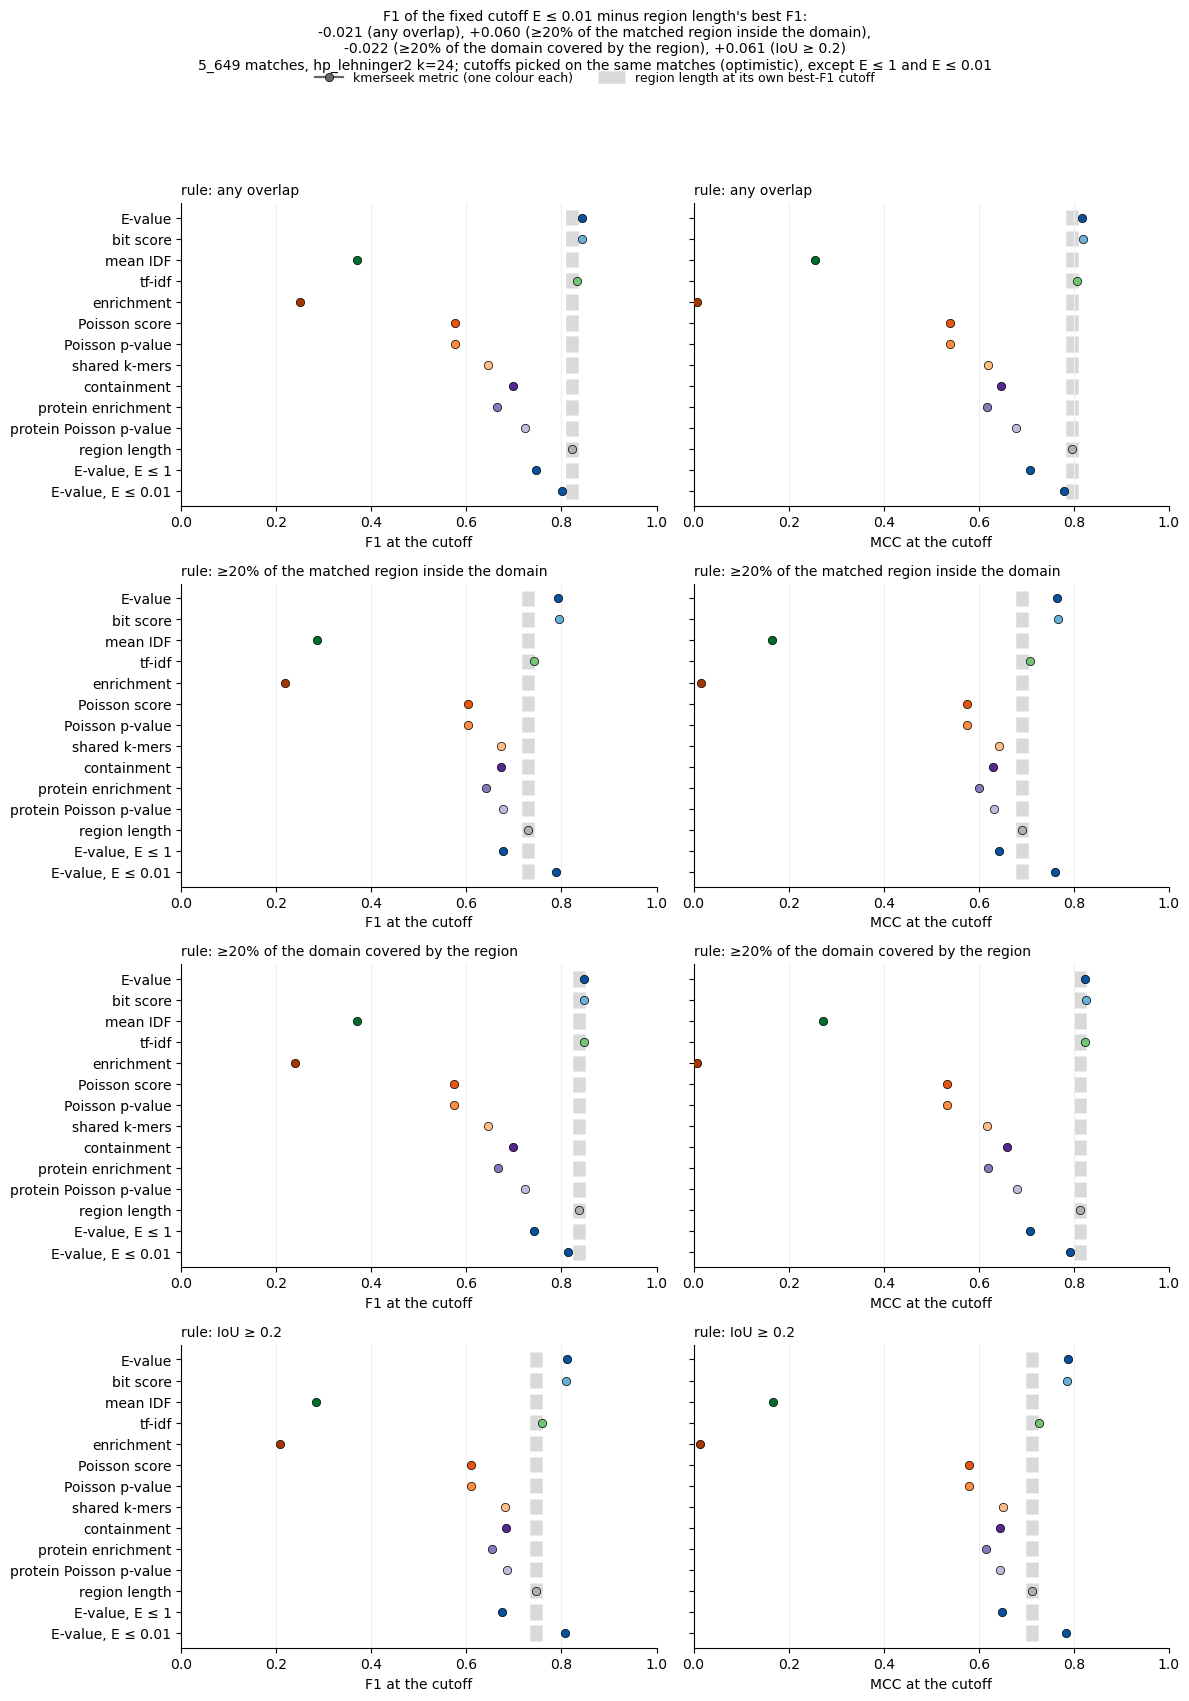

In [7]:
colmap = {n: c for c, _, n in rm.ALL}
tt = (thr.with_columns(pl.col("metric").replace_strict(colmap).alias("column"),
                       pl.when(pl.col("cutoff") == "best F1").then(pl.col("metric"))
                         .otherwise(pl.col("metric") + ", " + pl.col("cutoff")).alias("label")))
L = tt.filter(pl.col("metric") == "region length").select("rule", pl.col("f1").alias("length_f1"), pl.col("mcc").alias("length_mcc"))
tt = tt.join(L, on="rule")
fig, axes = plt.subplots(4, 2, figsize=(12, 17), sharey=True)
for i, r in enumerate(RULES):
    t = tt.filter(pl.col("rule") == rm.RULE_NAME[r])
    rm.forest(axes[i, 0], t, "f1", None, None, "length_f1", xlabel="F1 at the cutoff")
    rm.forest(axes[i, 1], t, "mcc", None, None, "length_mcc", xlabel="MCC at the cutoff")
    for ax in axes[i]:
        ax.set_title(f"rule: {rm.RULE_NAME[r]}", fontsize=10, loc="left")
rm.legend_row(fig, rm.handles("region length at its own best-F1 cutoff", dot_label="kmerseek metric (one colour each)"))
e01 = tt.filter(pl.col("cutoff") == "E ≤ 0.01").select("rule", (pl.col("f1") - pl.col("length_f1")).alias("d"))
dd = dict(e01.iter_rows())
parts = [f"{dd[rm.RULE_NAME[r]]:+.3f} ({rm.RULE_NAME[r]})" for r in RULES]
fig.suptitle("F1 of the fixed cutoff E ≤ 0.01 minus region length's best F1:\n"
             + ", ".join(parts[:2]) + ",\n" + ", ".join(parts[2:]) + "\n"
             "5_649 matches, hp_lehninger2 k=24; cutoffs picked on the same matches (optimistic), except E ≤ 1 and E ≤ 0.01",
             y=0.998, fontsize=10)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIG / "255_f1_mcc_by_rule.png", bbox_inches="tight")
print(tt.select("rule", "label", "value_at_cutoff", "f1", "length_f1", "mcc", "length_mcc"))

## 5. Ranking within one query protein

A search user reads the list for one query. Here each query's matches are sorted by the
metric; matches the metric cannot score go last. Only queries with at least one correct
match count. Tied matches are averaged over every order they could come in. "Random order"
is the same measure with no score at all.

In [8]:
pq = pl.concat([rm.per_query(df, r, COLS) for r in RULES])
for r in RULES:
    print(pq.filter(pl.col("rule") == rm.RULE_NAME[r]))

shape: (13, 5)
┌─────────────────────────┬─────────────┬───────────┬────────────────┬───────┐
│ metric                  ┆ rule        ┆ n_queries ┆ precision_at_1 ┆ mrr   │
│ ---                     ┆ ---         ┆ ---       ┆ ---            ┆ ---   │
│ str                     ┆ str         ┆ i64       ┆ f64            ┆ f64   │
╞═════════════════════════╪═════════════╪═══════════╪════════════════╪═══════╡
│ E-value                 ┆ any overlap ┆ 191       ┆ 0.887          ┆ 0.926 │
│ bit score               ┆ any overlap ┆ 191       ┆ 0.887          ┆ 0.926 │
│ mean IDF                ┆ any overlap ┆ 191       ┆ 0.673          ┆ 0.790 │
│ tf-idf                  ┆ any overlap ┆ 191       ┆ 0.914          ┆ 0.940 │
│ enrichment              ┆ any overlap ┆ 191       ┆ 0.285          ┆ 0.519 │
│ Poisson score           ┆ any overlap ┆ 191       ┆ 0.805          ┆ 0.866 │
│ Poisson p-value         ┆ any overlap ┆ 191       ┆ 0.805          ┆ 0.866 │
│ shared k-mers           ┆ any overl

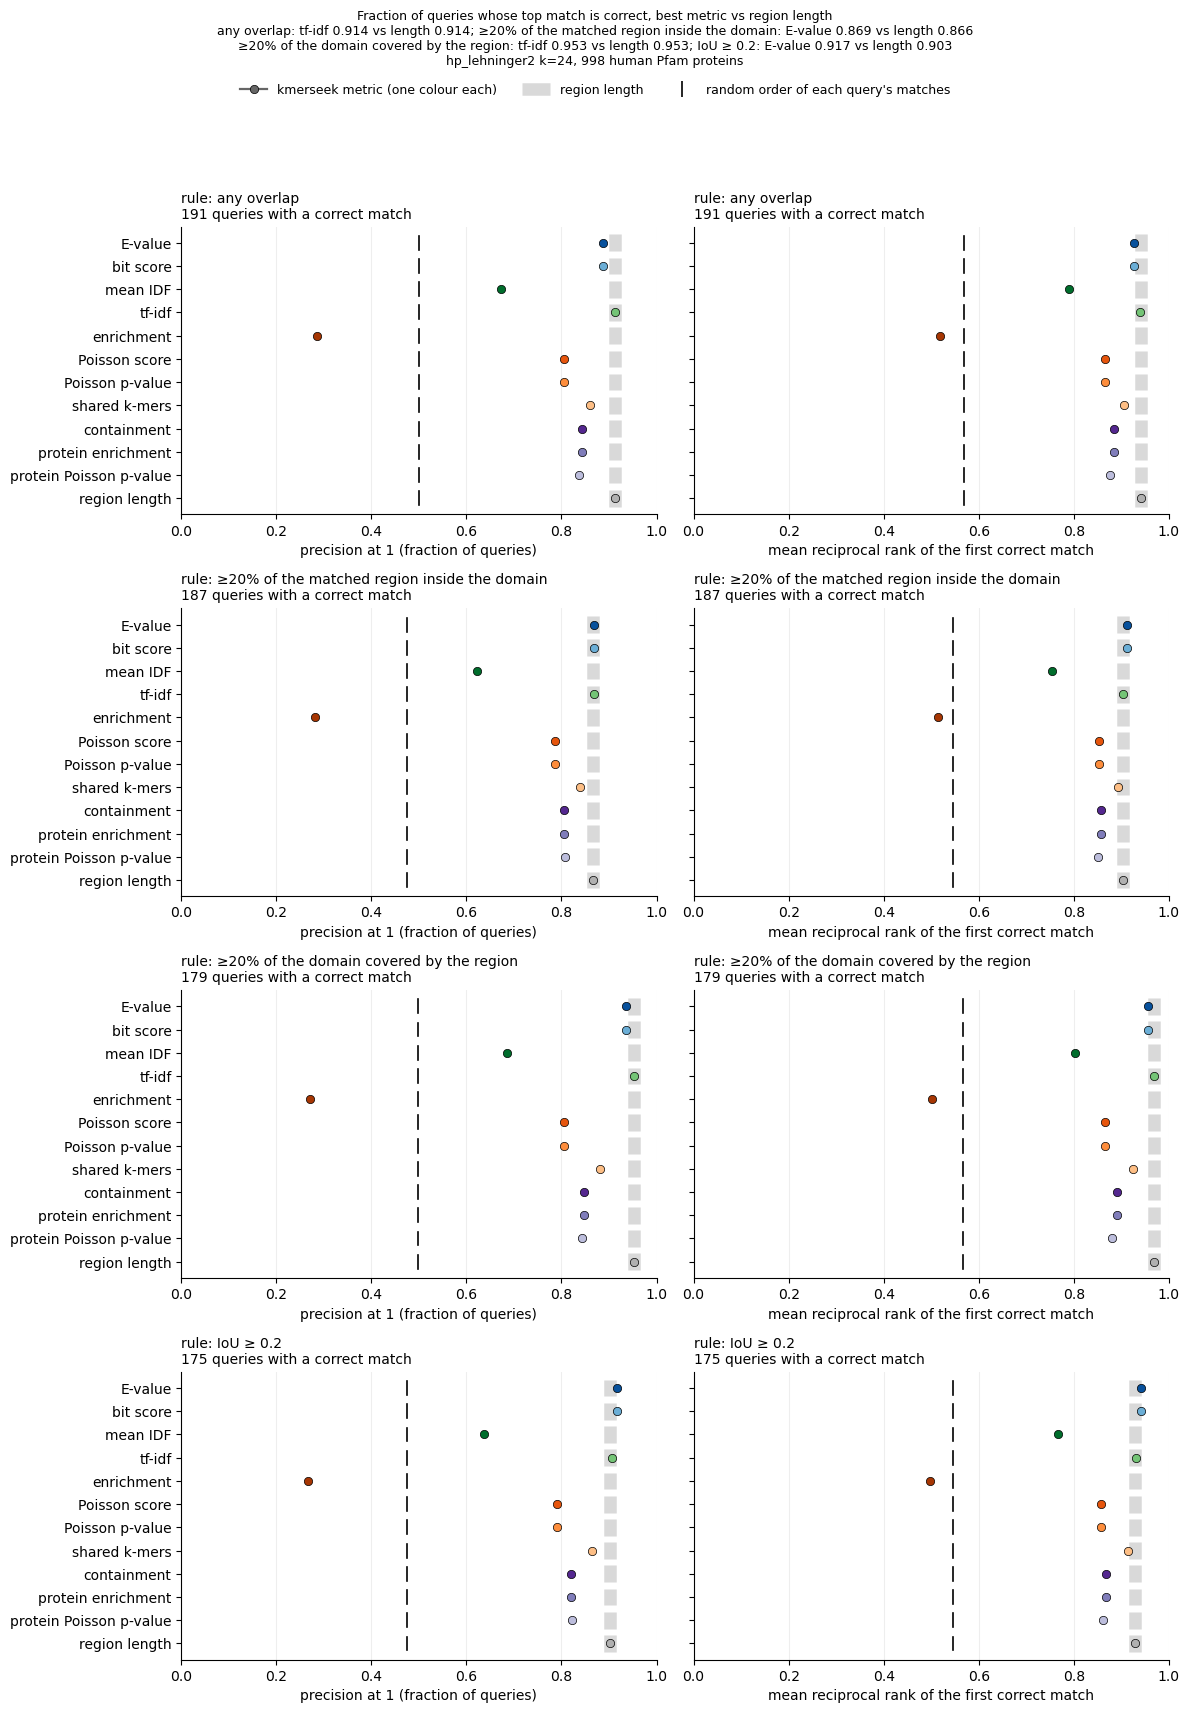

In [9]:
colmap["random order"] = "random"
pp = pq.filter(pl.col("metric") != "random order").with_columns(pl.col("metric").replace_strict(colmap).alias("column"))
ref = pq.filter(pl.col("metric").is_in(["random order", "region length"])).pivot(on="metric", index="rule",
                                                                                 values=["precision_at_1", "mrr"])
pp = pp.join(ref, on="rule")
fig, axes = plt.subplots(4, 2, figsize=(12, 17), sharey=True)
for i, r in enumerate(RULES):
    t = pp.filter(pl.col("rule") == rm.RULE_NAME[r])
    nq = t["n_queries"][0]
    rm.forest(axes[i, 0], t, "precision_at_1", None, None, "precision_at_1_region length",
              tick="precision_at_1_random order", xlabel="precision at 1 (fraction of queries)")
    rm.forest(axes[i, 1], t, "mrr", None, None, "mrr_region length", tick="mrr_random order",
              xlabel="mean reciprocal rank of the first correct match")
    for ax in axes[i]:
        ax.set_title(f"rule: {rm.RULE_NAME[r]}\n{nq} queries with a correct match", fontsize=10, loc="left")
rm.legend_row(fig, rm.handles("region length", "random order of each query's matches",
                              dot_label="kmerseek metric (one colour each)"))
tops = [pp.filter(pl.col("rule") == rm.RULE_NAME[r]).sort("precision_at_1", descending=True).row(0, named=True) for r in RULES]
parts = [f"{t['rule']}: {t['metric']} {t['precision_at_1']:.3f} vs length {t['precision_at_1_region length']:.3f}" for t in tops]
fig.suptitle("Fraction of queries whose top match is correct, best metric vs region length\n"
             + "; ".join(parts[:2]) + "\n" + "; ".join(parts[2:])
             + "\nhp_lehninger2 k=24, 998 human Pfam proteins", y=1.005, fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIG / "255_per_query_by_rule.png", bbox_inches="tight")

## 6. Within bins of region length

If a metric only repeats length, its lead should shrink once length is held within a
narrower range. The grey bar is length's own AUC inside the bin. The bins are wide, so
length still sorts matches inside them (AUC 0.66 to 0.81 in the three longer bins). The
shortest bin (24 to 29 aa; k = 24 sets the floor) holds 2 to 10 correct matches, so its
intervals are wide. The E-value and bit score score fewer matches in every bin.

In [10]:
bins = pl.concat([rm.length_bins(df, r, COLS, n_boot=N_BOOT) for r in RULES])
print(bins.select("rule", "length_bin", "metric", "n_scored", "n_correct", "base_rate", "auc", "auc_lo", "auc_hi",
                  "length_auc", "auc_minus_length", "auc_minus_length_lo", "auc_minus_length_hi", "ap", "length_ap"))
bdiff = bins.filter((pl.col("metric") != "region length")
                    & ((pl.col("auc_minus_length_lo") > 0) | (pl.col("auc_minus_length_hi") < 0)))
print("\nbins where a metric's AUC differs from length's (95% interval of the paired difference excludes 0):")
print(bdiff.select("rule", "length_bin", "metric", "n_correct", "auc", "length_auc", "auc_minus_length",
                   "auc_minus_length_lo", "auc_minus_length_hi").sort("rule", "length_bin", "auc_minus_length"))

shape: (192, 15)
┌──────────────────────────────────────────────┬────────────┬─────────────────────────┬──────────┬───────────┬───────────┬───────┬────────┬────────┬────────────┬──────────────────┬─────────────────────┬─────────────────────┬───────┬───────────┐
│ rule                                         ┆ length_bin ┆ metric                  ┆ n_scored ┆ n_correct ┆ base_rate ┆ auc   ┆ auc_lo ┆ auc_hi ┆ length_auc ┆ auc_minus_length ┆ auc_minus_length_lo ┆ auc_minus_length_hi ┆ ap    ┆ length_ap │
│ ---                                          ┆ ---        ┆ ---                     ┆ ---      ┆ ---       ┆ ---       ┆ ---   ┆ ---    ┆ ---    ┆ ---        ┆ ---              ┆ ---                 ┆ ---                 ┆ ---   ┆ ---       │
│ str                                          ┆ str        ┆ str                     ┆ i64      ┆ i64       ┆ f64       ┆ f64   ┆ f64    ┆ f64    ┆ f64        ┆ f64              ┆ f64                 ┆ f64                 ┆ f64   ┆ f64       │
╞══

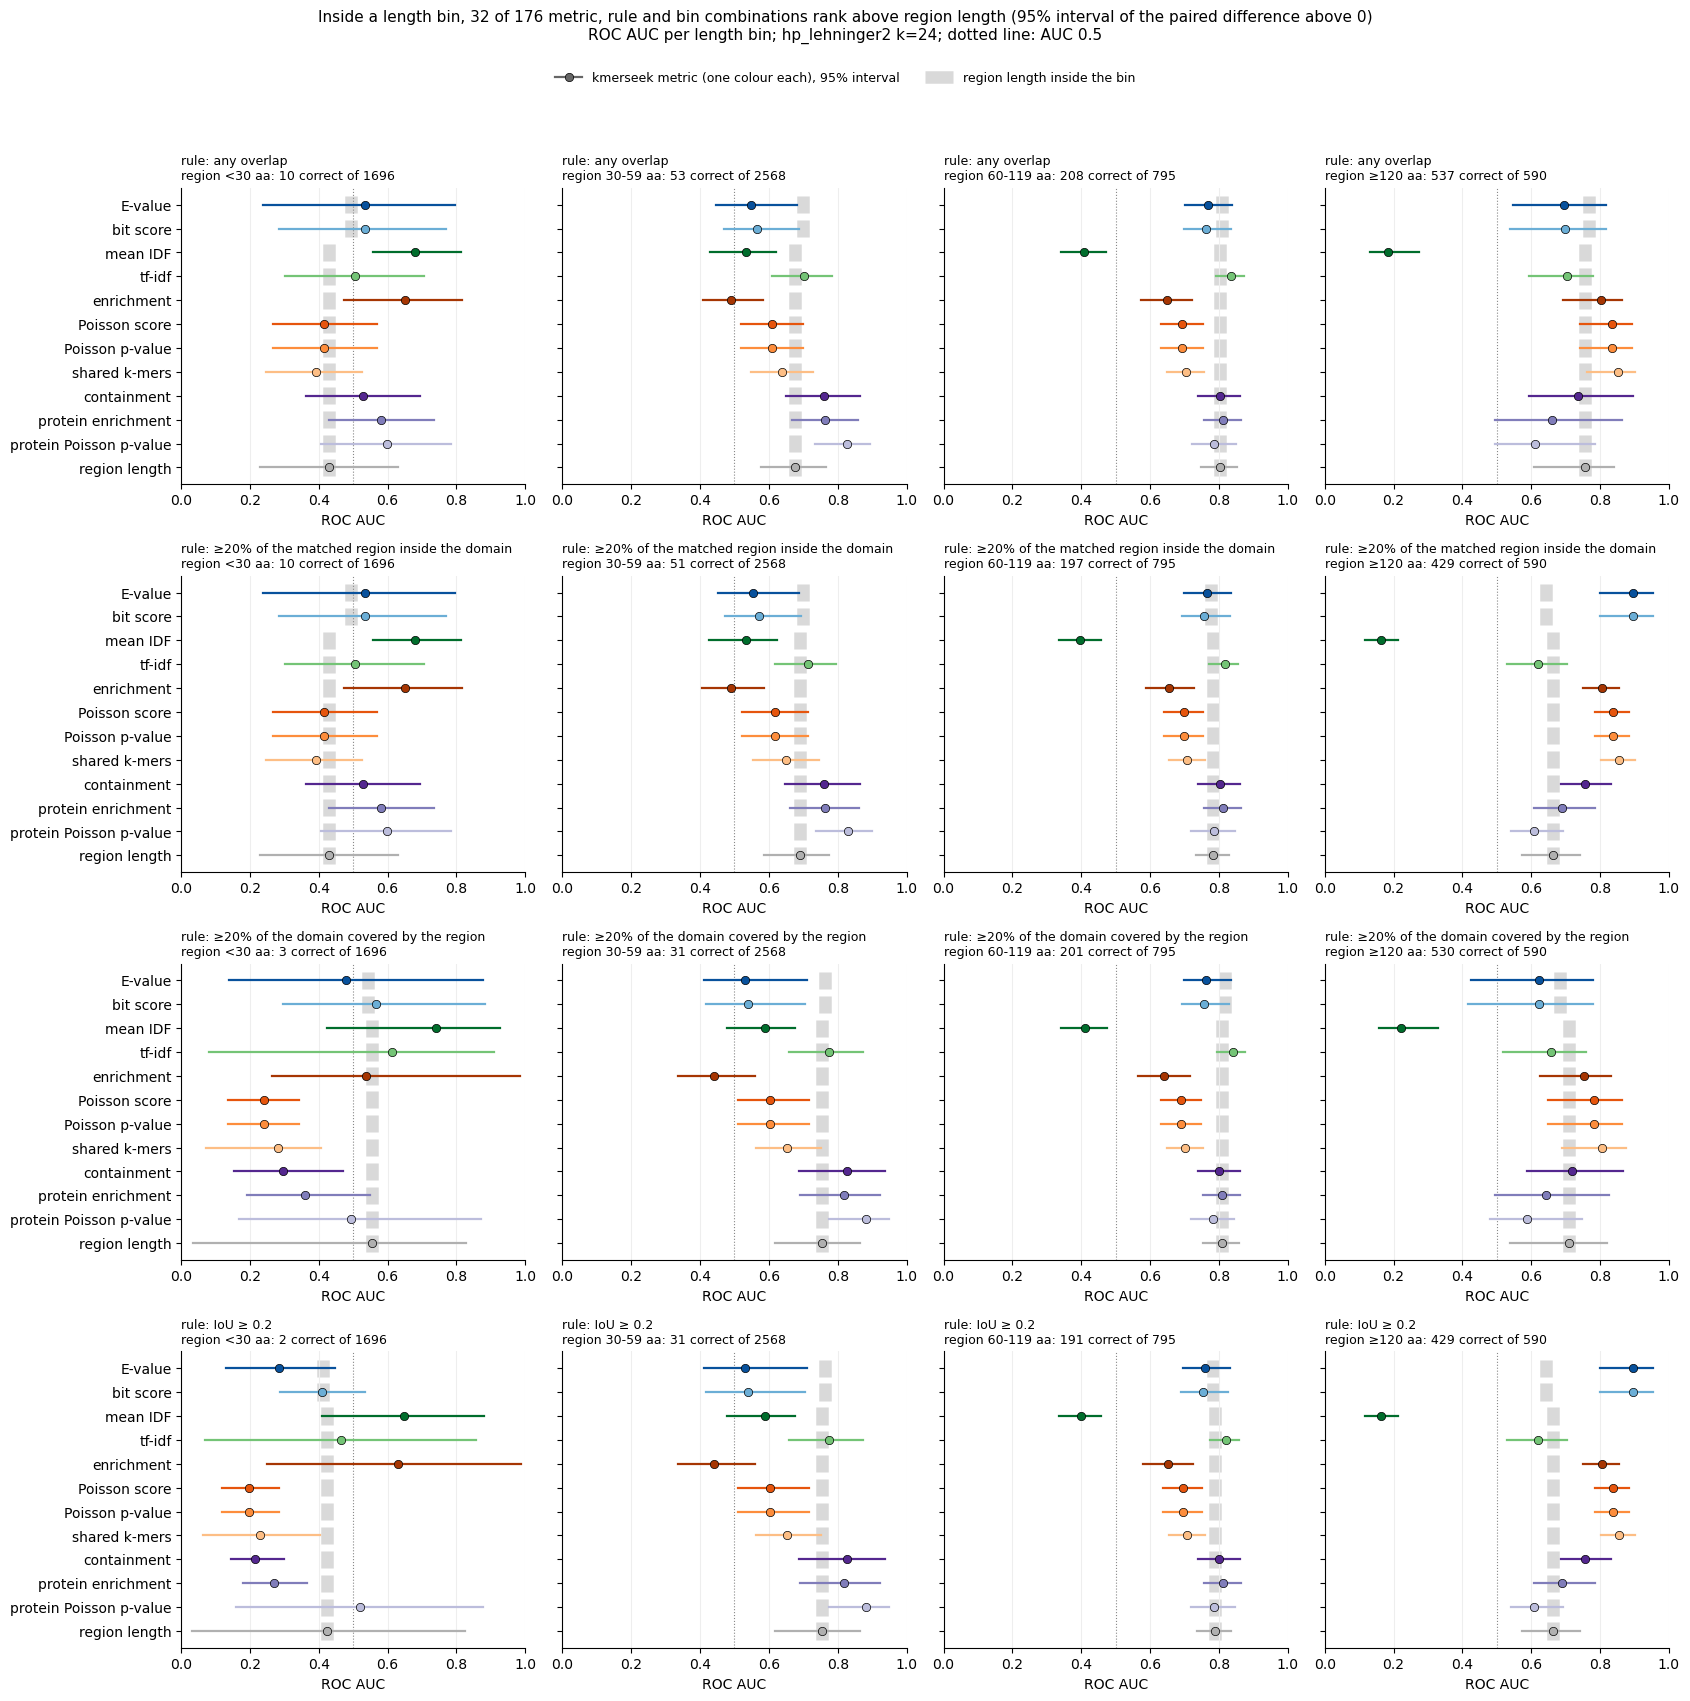

In [11]:
labs = [b[2] for b in rm.LENGTH_BINS]
fig, axes = plt.subplots(4, 4, figsize=(17, 17), sharey=True)
for i, r in enumerate(RULES):
    for j, lab in enumerate(labs):
        t = bins.filter((pl.col("rule") == rm.RULE_NAME[r]) & (pl.col("length_bin") == lab))
        ax = axes[i, j]
        rm.forest(ax, t, "auc", "auc_lo", "auc_hi", "length_auc", xlabel="ROC AUC", xlim=(0, 1), labels=(j == 0))
        ax.axvline(0.5, color="#888888", lw=0.8, ls=":")
        ax.set_title(f"rule: {rm.RULE_NAME[r]}\nregion {lab}: {t['n_correct'].max()} correct of {t['n_scored'].max()}",
                     fontsize=9, loc="left")
rm.legend_row(fig, rm.handles("region length inside the bin"))
n_up = bdiff.filter(pl.col("auc_minus_length") > 0).height
n_all = bins.filter(pl.col("metric") != "region length").height
fig.suptitle(f"Inside a length bin, {n_up} of {n_all} metric, rule and bin combinations rank above region length "
             "(95% interval of the paired difference above 0)\n"
             "ROC AUC per length bin; hp_lehninger2 k=24; dotted line: AUC 0.5", y=0.998, fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIG / "255_auc_by_length_bin.png", bbox_inches="tight")

## 7. Every alphabet and k (152 alphabet-ksize pairs of the notebook 243 search)

`255_ranking_metrics_per_arm.py` labels every region of every alphabet-ksize pair with the same rules and
keeps one row per pair of spans. That search kept every region kmerseek reported
(threshold 0, one shared k-mer, minimum region score 0), so each alphabet-ksize pair has more matches than
the 5_649 above: hp_lehninger2 k=24 has 8_731 there. Its search file does not carry
region_poisson_score, containment, query_enrichment or query_poisson_pvalue, so those four
cannot be scored per alphabet-ksize pair. No interval is computed per alphabet-ksize pair. When the two directions of a
pair have the same E-value (for example both infinite), the kept direction is the one whose
query name sorts first; the stored 5_649 file broke those ties another way (checked below).

In [12]:
# Cross-check: the hp_lehninger2 k=24 alphabet-ksize pair of the notebook 243 search against the stored
# any-overlap labels of the 11_298 directed hits the 5_649 matches were built from.
hits = pl.read_parquet(rm.LABELS.parent / "human_pfam_allvall_labeled_hits.parquet")
k = ["query_name", "target_name", "region_start", "region_end", "target_start", "target_end"]
a243 = rm.label_regions(pl.read_parquet(rm.PF998 / "regions" / "hp_lehninger2.k24.parquet"))
j = (hits.select(k + ["is_true_domain_match", "region_mean_idf"]).with_columns([pl.col(c).cast(pl.Float64) for c in k[2:]])
     .join(a243.select(k + ["correct_any_overlap", pl.col("region_mean_idf").alias("idf_243")]), on=k, how="inner"))
print(f"{hits.height:_} stored hits; {j.height:_} have the same coordinates in the notebook 243 alphabet-ksize pair; "
      f"labels disagree on {int((j['is_true_domain_match'] != j['correct_any_overlap']).sum())}; "
      f"mean IDF differs on {int(((j['region_mean_idf'] - j['idf_243']).abs() > 1e-6).sum())}")

# The one-row-per-pair step used for the alphabet-ksize pairs, applied to the stored hits.
m = rm.independent_matches(hits)
kept_other = df.join(m.select(k), on=k, how="anti")
print(f"independent_matches on the stored hits: {m.height:_} pairs (stored file: {df.height:_}); "
      f"{kept_other.height:_} pairs keep the other direction, all with tied E-values "
      f"({kept_other.filter(pl.col('region_evalue').is_infinite()).height:_} of them E = inf in both directions)")
swap = {"query_name": "target_name", "target_name": "query_name", "region_start": "target_start",
        "target_start": "region_start", "region_end": "target_end", "target_end": "region_end"}
tie_check = kept_other.select(k + ["region_evalue"]).join(
    m.select(k + [pl.col("region_evalue").alias("e_kept")]).rename(swap), on=k, how="inner")
assert tie_check.height == kept_other.height
assert (tie_check["region_evalue"] == tie_check["e_kept"]).all()

11_298 stored hits; 10_540 have the same coordinates in the notebook 243 alphabet-ksize pair; labels disagree on 0; mean IDF differs on 0
independent_matches on the stored hits: 5_649 pairs (stored file: 5_649); 1_062 pairs keep the other direction, all with tied E-values (1_017 of them E = inf in both directions)


In [13]:
arm = pl.read_parquet(rm.PER_ARM)
n_arms = arm.select("alphabet", "ksize").unique().height
print(f"{rm.PER_ARM}: {n_arms} alphabet-ksize pairs")
no_ka = arm.filter((pl.col("column") == "region_evalue") & (pl.col("rule") == "any overlap") & (pl.col("n_scored") == 0))
print(f"{no_ka.height} alphabet-ksize pairs have no E-value on any match (exact regions, no Karlin-Altschul fit)")
arm = arm.with_columns((pl.col("auc") - pl.col("length_auc")).alias("auc_minus_length"),
                       (pl.col("ap") - pl.col("length_ap")).alias("ap_minus_length"))
summary = (arm.filter(pl.col("column") != "region_length").drop_nulls("auc").filter(pl.col("auc").is_not_nan())
           .group_by("rule", "metric").agg(pl.len().alias("alphabet-ksize pairs scored"),
                                           (pl.col("auc_minus_length") > 0.01).sum().alias("alphabet-ksize pairs: AUC > length + 0.01"),
                                           (pl.col("auc_minus_length") < -0.01).sum().alias("alphabet-ksize pairs: AUC < length - 0.01"),
                                           pl.col("auc_minus_length").median().alias("median AUC - length AUC"),
                                           pl.col("auc_minus_length").max().alias("max AUC - length AUC"),
                                           (pl.col("ap_minus_length") > 0.01).sum().alias("alphabet-ksize pairs: AP > length + 0.01"))
           .sort("rule", "median AUC - length AUC", descending=[False, True]))
print(summary)
print("\nThe 10 alphabet-ksize pairs where a metric's AUC is furthest above length's, rules any overlap and IoU ≥ 0.2:")
print(arm.filter(pl.col("rule").is_in(["any overlap", "IoU ≥ 0.2"]) & (pl.col("column") != "region_length"))
      .filter(pl.col("auc_minus_length").is_not_nan()).drop_nulls("auc_minus_length")
      .sort("auc_minus_length", descending=True).head(10)
      .select("rule", "metric", "alphabet", "ksize", "bits", "n_scored", "n_correct", "base_rate", "auc", "length_auc",
              "auc_minus_length", "ap", "length_ap"))
print("\nhp_lehninger2 k=24 in the notebook 243 search:")
print(arm.filter((pl.col("alphabet") == "hp_lehninger2") & (pl.col("ksize") == 24))
      .select("rule", "metric", "n_matches", "n_scored", "base_rate", "auc", "length_auc", "ap", "length_ap",
              "precision_at_1", "precision_at_1_random"))

/Users/olga/data/botryllus/ranking-metrics/per_arm_metrics.parquet: 152 alphabet-ksize pairs
82 alphabet-ksize pairs have no E-value on any match (exact regions, no Karlin-Altschul fit)
shape: (28, 8)
┌─────────────────────────────────────┬─────────────────┬─────────────────────────────┬─────────────────────────────────────┬─────────────────────────────────────┬─────────────────────────┬──────────────────────┬─────────────────────────────────────┐
│ rule                                ┆ metric          ┆ alphabet-ksize pairs scored ┆ alphabet-ksize pairs: AUC > length  ┆ alphabet-ksize pairs: AUC < length  ┆ median AUC - length AUC ┆ max AUC - length AUC ┆ alphabet-ksize pairs: AP > length + │
│ ---                                 ┆ ---             ┆ ---                         ┆ + 0.01                              ┆ - 0.01                              ┆ ---                     ┆ ---                  ┆ 0.01                                │
│ str                                 ┆ str   


ROC AUC per alphabet-ksize pair, rule: any overlap (region length column: length over all matches of the alphabet-ksize pair)
shape: (152, 12)
┌──────────────────────────┬───────┬────────┬───────────┬─────────┬───────────┬──────────┬────────┬────────────┬─────────────────┬───────────────┬───────────────┐
│ alphabet                 ┆ ksize ┆ bits   ┆ n_matches ┆ E-value ┆ bit score ┆ mean IDF ┆ tf-idf ┆ enrichment ┆ Poisson p-value ┆ shared k-mers ┆ region length │
│ ---                      ┆ ---   ┆ ---    ┆ ---       ┆ ---     ┆ ---       ┆ ---      ┆ ---    ┆ ---        ┆ ---             ┆ ---           ┆ ---           │
│ str                      ┆ i64   ┆ f64    ┆ i64       ┆ f64     ┆ f64       ┆ f64      ┆ f64    ┆ f64        ┆ f64             ┆ f64           ┆ f64           │
╞══════════════════════════╪═══════╪════════╪═══════════╪═════════╪═══════════╪══════════╪════════╪════════════╪═════════════════╪═══════════════╪═══════════════╡
│ gbmr4                    ┆ 10    ┆ 15.2

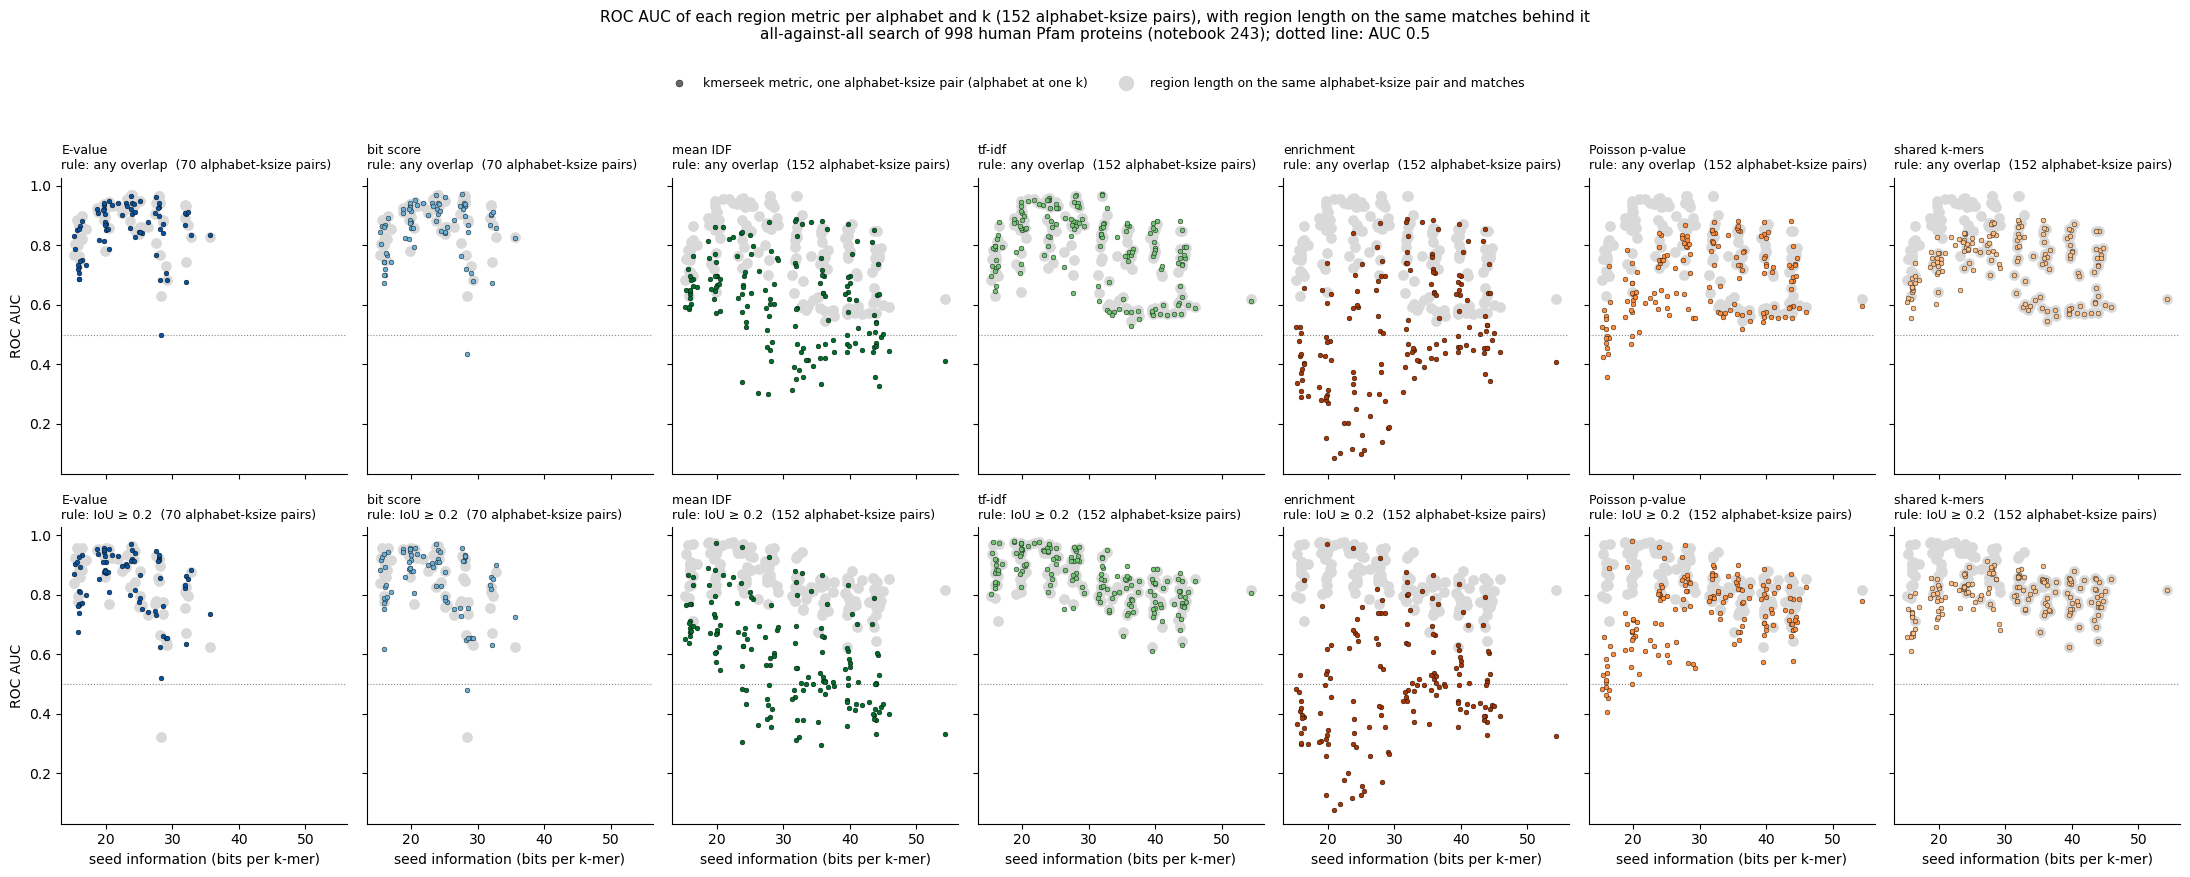

In [14]:
show_rules = ["any overlap", "IoU ≥ 0.2"]
mets = [c for c in ["region_evalue", "region_ka_bits", "region_mean_idf", "region_tfidf", "region_enrichment",
                    "region_tail_probability", "region_n_shared_kmers"]]
fig, axes = plt.subplots(len(show_rules), len(mets), figsize=(22, 8), sharex=True, sharey=True)
for i, rule in enumerate(show_rules):
    for j, c in enumerate(mets):
        ax = axes[i, j]
        t = arm.filter((pl.col("rule") == rule) & (pl.col("column") == c)).drop_nulls("auc").filter(pl.col("auc").is_not_nan())
        ax.scatter(t["bits"], t["length_auc"], s=60, color="#d9d9d9", lw=0, zorder=1)
        ax.scatter(t["bits"], t["auc"], s=12, color=rm.COLOR[c], edgecolor="black", lw=0.3, zorder=3)
        ax.axhline(0.5, color="#888888", lw=0.8, ls=":")
        ax.set_title(f"{rm.NAME[c]}\nrule: {rule}  ({t.height} alphabet-ksize pairs)", fontsize=9, loc="left")
        if i == len(show_rules) - 1:
            ax.set_xlabel("seed information (bits per k-mer)")
        if j == 0:
            ax.set_ylabel("ROC AUC")
from matplotlib.lines import Line2D
rm.legend_row(fig, [Line2D([], [], marker="o", color="#666666", mec="black", mew=0.3, ls="none", ms=5,
                           label="kmerseek metric, one alphabet-ksize pair (alphabet at one k)"),
                    Line2D([], [], marker="o", color="#d9d9d9", ls="none", ms=10,
                           label="region length on the same alphabet-ksize pair and matches")], y=1.02)
fig.suptitle(f"ROC AUC of each region metric per alphabet and k ({n_arms} alphabet-ksize pairs), with region length on the same matches behind it\n"
             "all-against-all search of 998 human Pfam proteins (notebook 243); dotted line: AUC 0.5", y=1.09, fontsize=11)
fig.tight_layout()
fig.savefig(FIG / "255_auc_per_arm.png", bbox_inches="tight")
for rule in show_rules:
    w = (arm.filter((pl.col("rule") == rule) & pl.col("column").is_in(mets + ["region_length"]))
         .pivot(on="metric", index=["alphabet", "ksize", "bits", "n_matches"], values="auc").sort("bits"))
    print(f"\nROC AUC per alphabet-ksize pair, rule: {rule} (region length column: length over all matches of the alphabet-ksize pair)")
    print(w)

### All 19 alphabets on one page

The figure above asks the reader to pair each coloured dot with the grey dot behind it. This
grid shows the difference directly. Each cell is one alphabet and one metric: the metric's
average precision minus region length's on the same matches, as the median over that
alphabet's k-mer sizes, under IoU ≥ 0.2. Average precision is used rather than AUC because
at the small k-mer sizes almost no match is correct, and there AUC looks good while the top
of the list is nearly all wrong. Blue: the metric puts correct matches higher than length
alone does. Red: lower. n: the number of alphabet-ksize pairs in the median (the E-value and
bit score exist only where the index has a Karlin-Altschul fit).

shape: (19, 8)
┌──────────────────────────┬─────────┬───────────┬────────┬───────────────┬─────────────────┬──────────┬────────────┐
│ alphabet                 ┆ E-value ┆ bit score ┆ tf-idf ┆ shared k-mers ┆ Poisson p-value ┆ mean IDF ┆ enrichment │
│ ---                      ┆ ---     ┆ ---       ┆ ---    ┆ ---           ┆ ---             ┆ ---      ┆ ---        │
│ str                      ┆ f64     ┆ f64       ┆ f64    ┆ f64           ┆ f64             ┆ f64      ┆ f64        │
╞══════════════════════════╪═════════╪═══════════╪════════╪═══════════════╪═════════════════╪══════════╪════════════╡
│ dayhoff6                 ┆ -0.014  ┆ -0.012    ┆ 0.034  ┆ 0.000         ┆ -0.044          ┆ -0.185   ┆ -0.186     │
│ funcgroups8              ┆ 0.000   ┆ 0.010     ┆ 0.006  ┆ 0.000         ┆ -0.105          ┆ -0.317   ┆ -0.366     │
│ gbmr4                    ┆ -0.006  ┆ -0.006    ┆ 0.008  ┆ 0.104         ┆ 0.084           ┆ -0.220   ┆ -0.163     │
│ gbmr7                    ┆ -0.113  ┆ -0

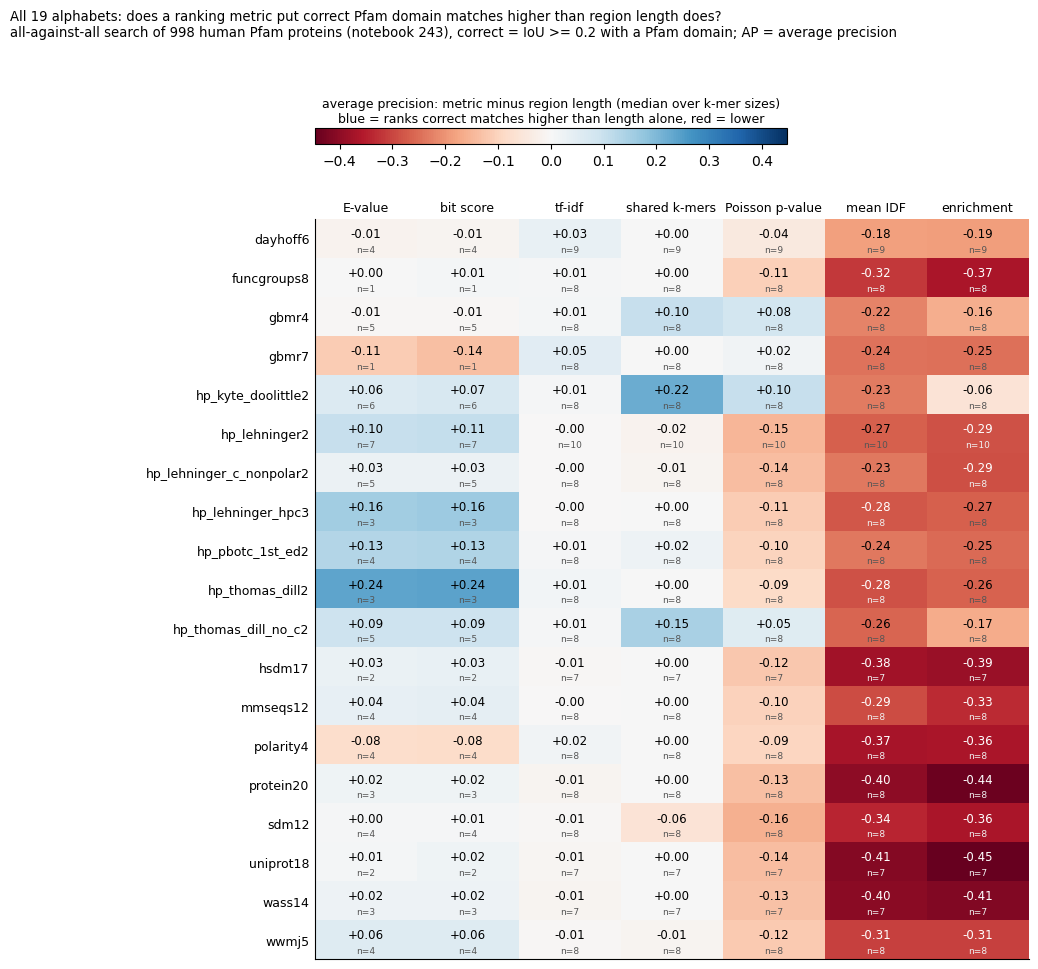

In [15]:
gain = rm.gain_over_length(arm, "IoU ≥ 0.2", "ap")
rm.fig_gain_grid(
    gain, FIG / "255_all_alphabets_ap_gain_over_length.png",
    "All 19 alphabets: does a ranking metric put correct Pfam domain matches higher than region length does?\n"
    "all-against-all search of 998 human Pfam proteins (notebook 243), correct = IoU >= 0.2 with a Pfam domain; AP = average precision",
    "average precision")
print(gain.pivot(on="metric", index="alphabet", values="median_gain").select(["alphabet"] + rm.GRID_METRICS)
          .with_columns(pl.exclude("alphabet").round(3)).sort("alphabet"))
print("\nalphabets where the metric's median is above length's (of 19):")
print(gain.group_by("metric").agg((pl.col("median_gain") > 0).sum().alias("alphabets above length"),
                                  pl.col("median_gain").median().round(3).alias("median over alphabets")).sort("metric"))

## 8. Checks

One AUC by hand with scikit-learn on the raw columns, and the count of matches each metric
scored.

In [16]:
y = df["correct_any_overlap"].to_numpy()
t = boot.filter(pl.col("rule") == "any overlap")
hand_tfidf = roc_auc_score(y, df["region_tfidf"].to_numpy())
ok = df["region_ka_lambda"].to_numpy() > 0
hand_e = roc_auc_score(y[ok], -df["region_evalue"].to_numpy()[ok])
hand_len = roc_auc_score(y, df["region_length"].to_numpy())
print(pl.DataFrame({"metric": ["tf-idf", "E-value (lambda > 0 only)", "region length"],
                    "sklearn on the raw column": [hand_tfidf, hand_e, hand_len],
                    "table": [t.filter(pl.col("metric") == m)["auc"][0] for m in ["tf-idf", "E-value", "region length"]]}))
assert abs(hand_tfidf - t.filter(pl.col("metric") == "tf-idf")["auc"][0]) < 1e-12
assert abs(hand_e - t.filter(pl.col("metric") == "E-value")["auc"][0]) < 1e-12
print(t.select("metric", "n_scored", (df.height - pl.col("n_scored")).alias("not scored")))
from scipy.stats import spearmanr
print(f"Spearman rho, region_tfidf vs region_length over the 5_649 matches: "
      f"{spearmanr(df['region_tfidf'].to_numpy(), df['region_length'].to_numpy()).statistic:.3f}")

shape: (3, 3)
┌───────────────────────────┬───────────────────────────┬───────┐
│ metric                    ┆ sklearn on the raw column ┆ table │
│ ---                       ┆ ---                       ┆ ---   │
│ str                       ┆ f64                       ┆ f64   │
╞═══════════════════════════╪═══════════════════════════╪═══════╡
│ tf-idf                    ┆ 0.961                     ┆ 0.961 │
│ E-value (lambda > 0 only) ┆ 0.925                     ┆ 0.925 │
│ region length             ┆ 0.959                     ┆ 0.959 │
└───────────────────────────┴───────────────────────────┴───────┘
shape: (12, 3)
┌─────────────────────────┬──────────┬────────────┐
│ metric                  ┆ n_scored ┆ not scored │
│ ---                     ┆ ---      ┆ ---        │
│ str                     ┆ i64      ┆ i64        │
╞═════════════════════════╪══════════╪════════════╡
│ E-value                 ┆ 3644     ┆ 2005       │
│ bit score               ┆ 3644     ┆ 2005       │
│ mean IDF   

## 9. Conclusions

Numbers are for hp_lehninger2 k=24 on the 5_649 matches unless a line says otherwise. The
four rules are given in the order any overlap / ≥20% of the region inside the domain /
≥20% of the domain covered / IoU ≥ 0.2.

1. Region length alone has ROC AUC 0.959 / 0.941 / 0.974 / 0.960 and average precision
   0.878 / 0.729 / 0.885 / 0.751, against base rates of 0.143 / 0.122 / 0.135 / 0.116.
2. No kmerseek metric has a ROC AUC above length's on the same matches with the 95%
   interval of the difference above 0 (0 of 44 metric and rule pairs). tf-idf comes
   closest: its AUC is within 0.002 of length's and its AP within 0.010, under every rule.
3. The E-value and bit score rank the same way. They score 3_644 matches; the other 2_005
   have no Karlin-Altschul lambda, and only 6 of those 2_005 are correct under any overlap
   (2 under IoU ≥ 0.2). On the 3_644 they score, their ROC AUC is below length's
   (-0.042 any overlap, -0.027 IoU ≥ 0.2), but their AP is above length's under the two
   ≥20% of the region rule and IoU ≥ 0.2: +0.056 (interval 0.009 to 0.109)
   and +0.055 (0.007 to 0.111).
4. At a fixed cutoff, E ≤ 0.01 gives F1 0.801 / 0.789 / 0.814 / 0.808 and MCC
   0.779 / 0.761 / 0.792 / 0.783. Region length at its own best cutoff (picked on these
   same matches) gives F1 0.823 / 0.729 / 0.837 / 0.746 and MCC 0.796 / 0.692 / 0.812 /
   0.713. E ≤ 1 calls more matches (recall 0.877, precision 0.650 under any overlap).
   Accuracy is 0.90 to 0.96 for most metrics, but calling nothing already gives 0.857 to
   0.884, so accuracy says little here.
5. Three metrics rank worse than length by a wide margin: mean IDF (AUC 0.65 to 0.71),
   enrichment (0.29 to 0.35, below a coin toss, so a higher enrichment goes with an
   incorrect match), and the region Poisson score (0.71 to 0.76). The region Poisson
   p-value is a function of the Poisson score and gives the same ranking.
6. Per query protein, the top match is correct for 0.914 of queries with tf-idf and 0.914
   with length under any overlap (E-value 0.887, random order 0.499). Under IoU ≥ 0.2 the
   E-value leads: 0.917, against 0.906 for tf-idf and 0.903 for length.
7. Inside length bins some metrics do beat length. For matches of 120 aa or longer, under
   the ≥20% of the region rule and IoU ≥ 0.2, the E-value has AUC 0.896 against 0.644 for length on
   the same matches (difference 0.137 to 0.351), and shared k-mers 0.854 against 0.662.
   For 30 to 59 aa matches the whole-protein Poisson p-value has AUC 0.827 against 0.676
   (any overlap). tf-idf stays within 0.08 of length in every bin.
8. Across the 152 alphabet and k combinations of the notebook 243 search, tf-idf's median
   AUC minus length's AUC is 0.000 to 0.004 depending on the rule. Mean IDF and enrichment
   have an AUC more than 0.01 below length's in 139 to 144 of 152 alphabet-ksize pairs. Only 70 alphabet-ksize pairs have an E-value; its AP is
   more than 0.01 above length's in 57 of the 70 under IoU ≥ 0.2 and in 26 under any
   overlap. The largest AUC gains over length (up to +0.18, funcgroups8 k=6 and gbmr7
   k=10 under IoU ≥ 0.2) come from alphabet-ksize pairs with 5 to 7 million matches and a base rate of
   0.001 or below. There mean IDF and enrichment have AP 0.002 to 0.008 against 0.141 to
   0.199 for length: a higher AUC with almost no correct matches at the top of the list.

Region length is the number to beat. Over all matches only tf-idf ties it, and tf-idf
follows length closely (Spearman rho in section 8). The E-value adds something the length does not carry: it sorts
long matches by whether they land inside the domain, and a missing E-value marks a match
that is almost never correct.

Not computed: intervals per alphabet-ksize pair; the four protein-level and Poisson-score columns per alphabet-ksize pair
(not kept by `243_pfam998_search.py`); mean reciprocal rank per alphabet-ksize pair. Precision at 1 per
alphabet-ksize pair is in `per_arm_metrics.parquet` but not drawn.